# Búsqueda de mejor modelo con cortes preestablecidos

## Modelos iniciales

In [56]:
# IMPORTACIÓN DE LIBRERÍAS

# 1. Librerías del sistema y control de entorno
import warnings

# 2. Librerías de terceros (Análisis de datos y visualización)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 3. Modelos y Algoritmos de Machine Learning
from catboost import CatBoostClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 4. Herramientas de Scikit-Learn (Preprocesamiento, validación y métricas)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [57]:
# =========================
# 2. Configuración
# =========================

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "GDM1"

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=RANDOM_STATE,
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
}

# CV específico para generar predicciones out-of-fold en los gráficos.
# Es equivalente a lo que hacías en el script original con StratifiedKFold.
cv_plot = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [58]:
# =========================
# 3. Carga de dataset y split
# =========================

df_clinico = pd.read_pickle("df_clinico.pkl")

y = df_clinico[TARGET].astype(int)
X = df_clinico.drop(columns=[TARGET]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Shape X:", X.shape)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Columnas:", X.columns.tolist())
print("Distribución target:\n", y.value_counts())

Shape X: (1878, 7)
Shape X_train: (1502, 7)
Shape X_test: (376, 7)
Columnas: ['diabetes franca 1T', 'etnia', 'factores riesgo', 'edad>=35', 'obesidad', 'gluc 1t>100', 'hba1c 1t>5,7']
Distribución target:
 GDM1
0    1775
1     103
Name: count, dtype: int64


In [59]:
# =========================
# 4. Funciones de preprocesado
# =========================

def get_columnas_por_tipo(X_df):
    """Devuelve columnas numéricas y categóricas igual que en el script original."""
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c])
        and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]
    return num_cols, cat_cols


def construir_pipeline(X_df, modelo, escalar=False):
    """
    Construye el pipeline completo de preprocesado + modelo.

    Esta versión replica la lógica original:
    - Imputación mediana en numéricas.
    - StandardScaler solo cuando corresponde.
    - Imputación moda en categóricas.
    - OneHotEncoder con handle_unknown='ignore', drop='if_binary' y sparse_output=False.
    """
    num_cols, cat_cols = get_columnas_por_tipo(X_df)

    if escalar:
        num_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        num_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse_output=False
        ))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipeline, num_cols),
            ("cat", cat_pipeline, cat_cols),
        ]
    )

    model = Pipeline([
        ("prep", pre),
        ("clf", modelo)
    ])

    return model

In [60]:
# =========================
# 5. Funciones de evaluación y gráficos
# =========================

def evaluar_modelo_cv(nombre, estimator, X_train, y_train, cv, scoring):
    """Calcula métricas CV y devuelve filas para la tabla final."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scores = cross_validate(
            estimator,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

    resultados = []

    for metrica in scoring.keys():
        valores = scores[f"test_{metrica}"]
        mean = np.mean(valores)
        std = np.std(valores, ddof=1)
        ci95 = 1.96 * std / np.sqrt(len(valores))

        resultados.append(
            {
                "modelo": nombre,
                "metrica": metrica,
                "mean": mean,
                "std": std,
                "ci95_low": mean - ci95,
                "ci95_high": mean + ci95,
            }
        )

    return resultados


def plot_matriz_confusion_y_roc(nombre, estimator, X_train, y_train, cv_plot):
    """
    Genera los mismos gráficos del script original:
    - Matriz de confusión en CV.
    - Curva ROC en CV.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        y_pred_cv = cross_val_predict(
            estimator,
            X_train,
            y_train,
            cv=cv_plot,
            method="predict",
        )

        y_proba_cv = cross_val_predict(
            estimator,
            X_train,
            y_train,
            cv=cv_plot,
            method="predict_proba",
        )[:, 1]

    roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matriz de confusión
    cm = confusion_matrix(y_train, y_pred_cv)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No", "Sí"],
    )
    disp.plot(
        ax=axes[0],
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )
    axes[0].set_title(f"Matriz de confusión - {nombre} (CV)")

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
    axes[1].plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC = {roc_auc_cv:.3f})",
        linewidth=2,
    )
    axes[1].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Clasificador aleatorio",
    )
    axes[1].set_xlabel("FPR (1 - especificidad)")
    axes[1].set_ylabel("TPR (sensibilidad)")
    axes[1].set_title(f"Curva ROC - {nombre} (CV)")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()



In [61]:
# =========================
# 6. Modelos candidatos
# =========================

modelos = {
    "Regresión logística": {
        "estimator": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear"
        ),
        "escalar": True,
    },

    "RandomForest": {
        "estimator": RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "escalar": False,
    },

    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_depth=6,
            min_samples_leaf=20,
            random_state=42
        ),
        "escalar": False,
    },

    "ExtraTreesClassifier": {
        "estimator": ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "escalar": False,
    },

    "CatBoost": {
        "estimator": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            min_data_in_leaf=20,
            random_state=42,
            verbose=0
        ),
        "escalar": False,
    },

    "SVM (RBF)": {
        "estimator": SVC(
            kernel="rbf",
            C=0.5,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ),
        "escalar": True,
    },

    "MLP": {
        "estimator": MLPClassifier(
            hidden_layer_sizes=(100, 50),
            max_iter=500,
            random_state=42
        ),
        "escalar": True,
    },

    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            min_samples_leaf=20,
            subsample=0.9,
            random_state=42
        ),
        "escalar": False,
    },

    "XGBoost": {
        "estimator": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "escalar": False,
    },
}

print("Modelos a evaluar:")
for nombre in modelos.keys():
    print("-", nombre)

Modelos a evaluar:
- Regresión logística
- RandomForest
- HistGradientBoosting
- ExtraTreesClassifier
- CatBoost
- SVM (RBF)
- MLP
- GradientBoosting
- XGBoost



Evaluando modelo: Regresión logística


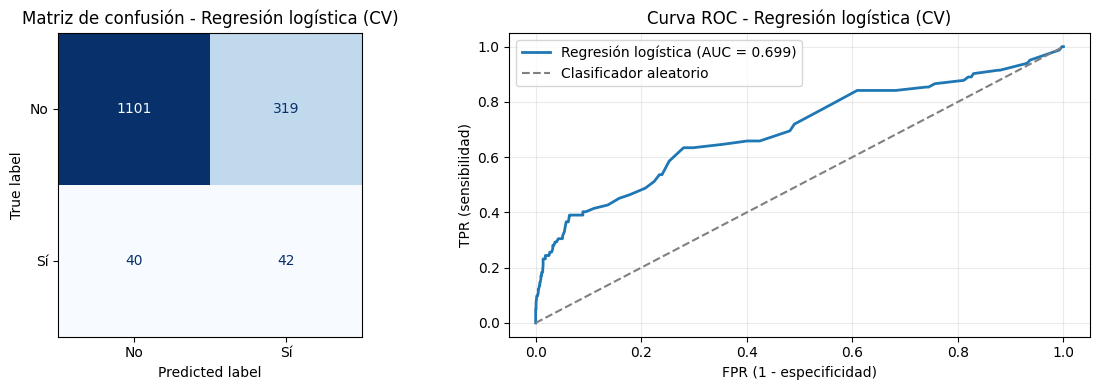


Evaluando modelo: RandomForest


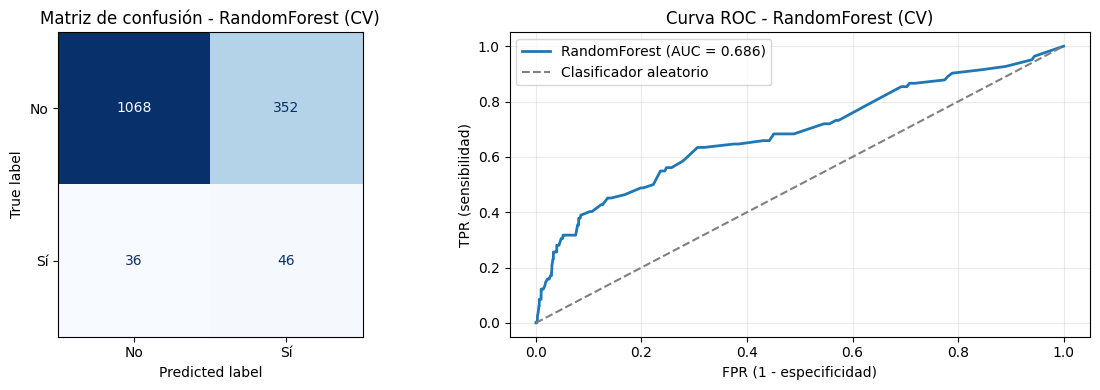


Evaluando modelo: HistGradientBoosting


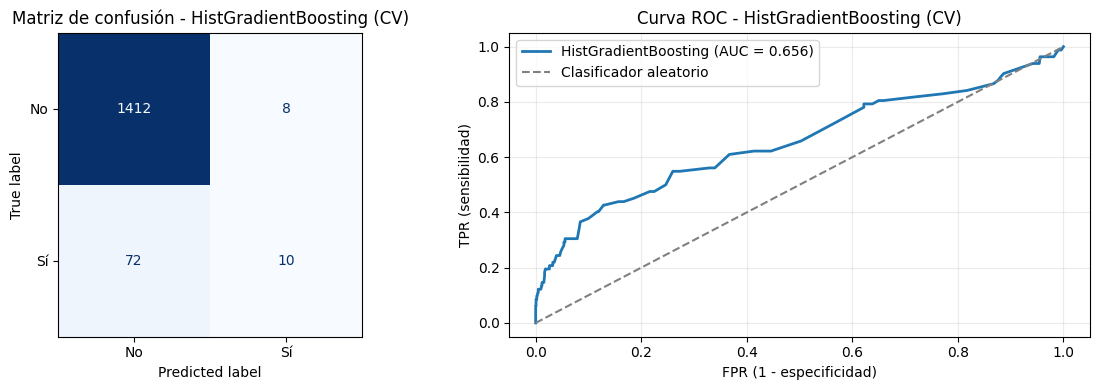


Evaluando modelo: ExtraTreesClassifier


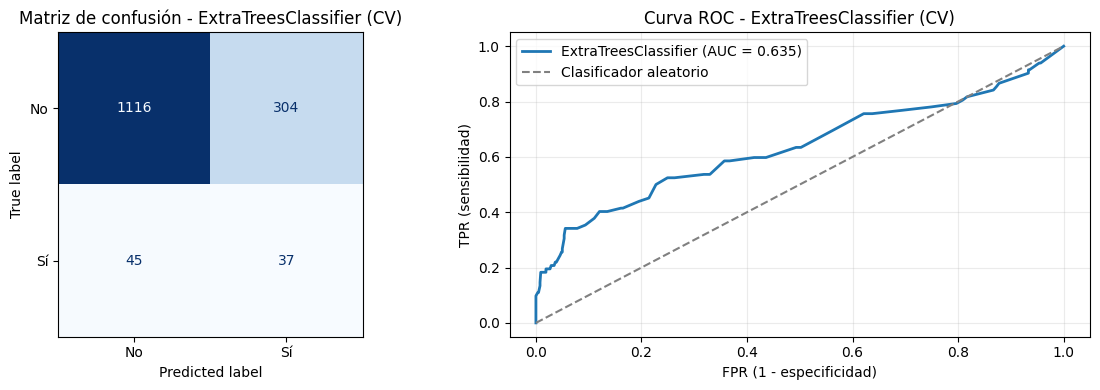


Evaluando modelo: CatBoost


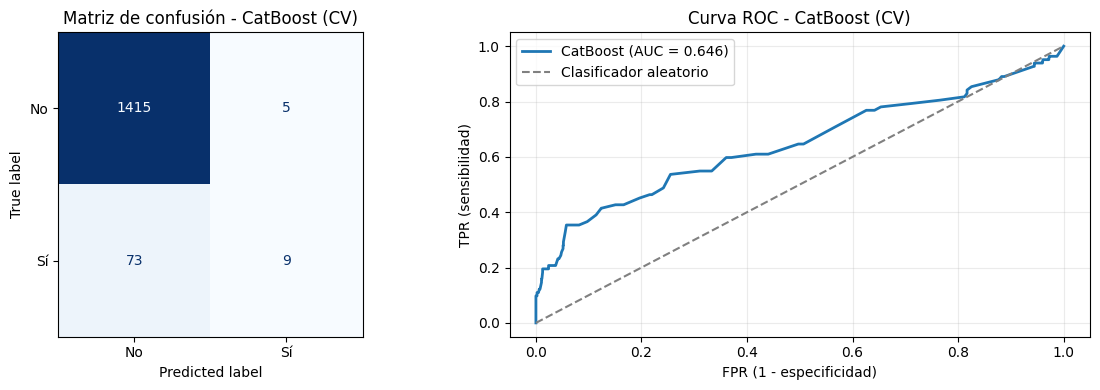


Evaluando modelo: SVM (RBF)


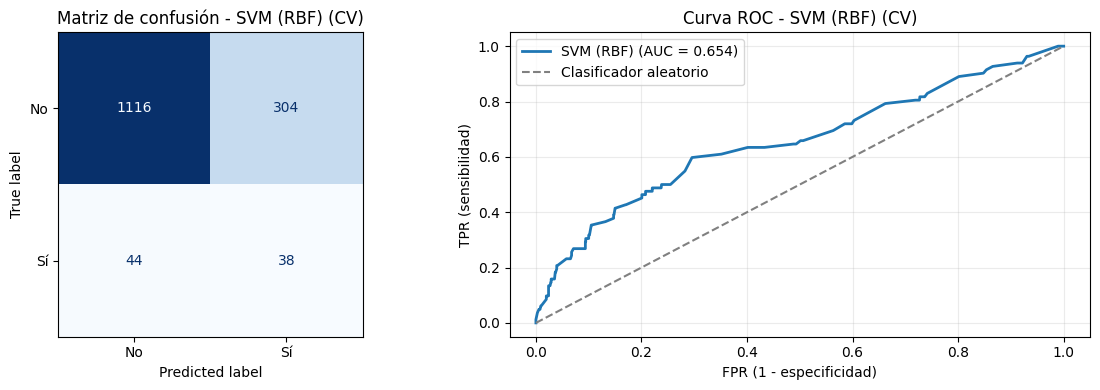


Evaluando modelo: MLP


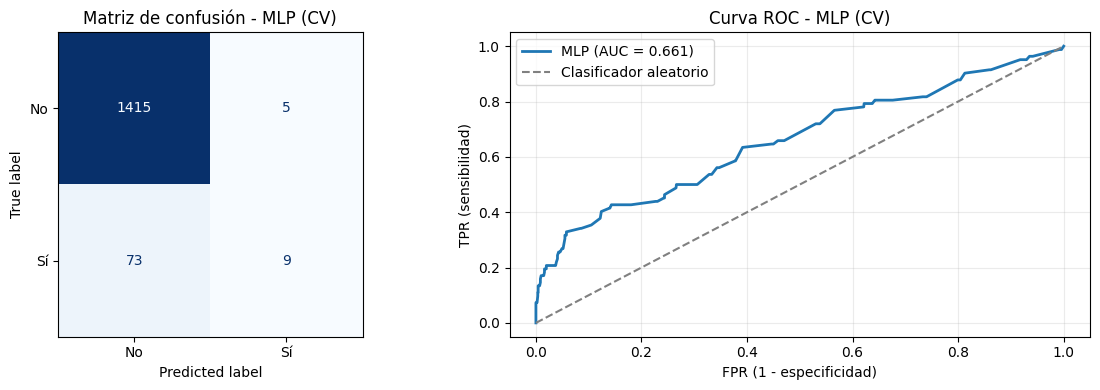


Evaluando modelo: GradientBoosting


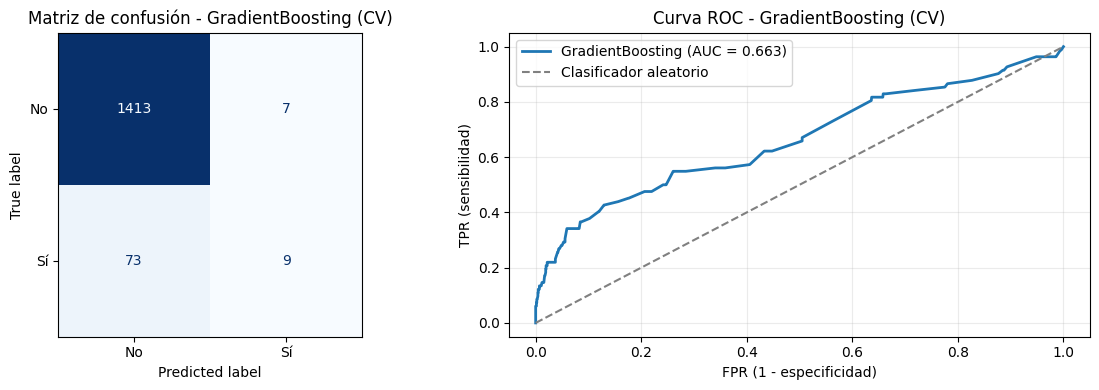


Evaluando modelo: XGBoost


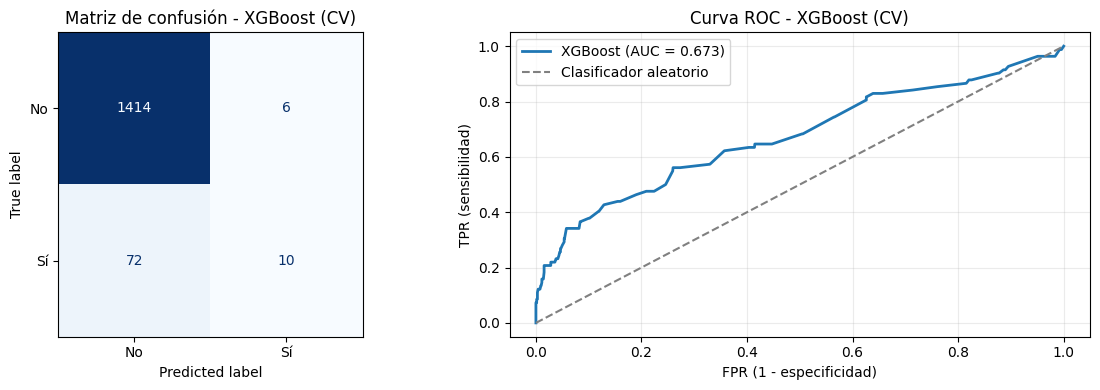

In [62]:
# =========================
# 7. Evaluación de modelos y gráficos por modelo
# =========================

resultados_modelos = []
pipelines = {}

for nombre, config in modelos.items():
    print("\n" + "=" * 85)
    print(f"Evaluando modelo: {nombre}")
    print("=" * 85)

    pipe = construir_pipeline(
        X_train,
        modelo=config["estimator"],
        escalar=config["escalar"],
    )

    pipelines[nombre] = pipe

    resultados_modelo = evaluar_modelo_cv(
        nombre=nombre,
        estimator=pipe,
        X_train=X_train,
        y_train=y_train,
        cv=cv,
        scoring=scoring,
    )
    resultados_modelos.extend(resultados_modelo)

    plot_matriz_confusion_y_roc(
        nombre=nombre,
        estimator=pipe,
        X_train=X_train,
        y_train=y_train,
        cv_plot=cv_plot,
    )



In [63]:
# =========================
# 8. Tabla comparativa CV
# =========================

res_cv = pd.DataFrame(resultados_modelos)

tabla_cv = (
    res_cv.pivot_table(
        index="modelo",
        columns="metrica",
        values="mean",
        aggfunc="first",
    )
    .reindex(columns=["roc_auc", "pr_auc", "f1"])
    .sort_values("roc_auc", ascending=False)
)

print("\n" + "=" * 85)
print("TABLA RESUMEN CV (métricas en validación cruzada)")
print("=" * 85)
display(tabla_cv.round(4))




TABLA RESUMEN CV (métricas en validación cruzada)


metrica,roc_auc,pr_auc,f1
modelo,,,
Regresión logística,0.7160,0.2712,0.1946
RandomForest,0.7006,0.2078,0.1897
XGBoost,0.6920,0.2556,0.1792
MLP,0.6908,0.2552,0.1556
GradientBoosting,0.6900,0.2547,0.1650
HistGradientBoosting,0.6885,0.2530,0.1720
CatBoost,0.6649,0.2520,0.1768
SVM (RBF),0.6631,0.1794,0.1978
ExtraTreesClassifier,0.6527,0.2362,0.1886


In [64]:
# =========================
# 9. Detalle ROC-AUC con IC95
# =========================

detalle_cv_roc = (
    res_cv[res_cv["metrica"] == "roc_auc"]
    .sort_values("mean", ascending=False)[
        ["modelo", "mean", "std", "ci95_low", "ci95_high"]
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 85)
print("DETALLE CV ROC-AUC (mean ± std, IC95)")
print("=" * 85)
display(detalle_cv_roc.round(4))


DETALLE CV ROC-AUC (mean ± std, IC95)


,modelo,mean,std,ci95_low,ci95_high
0,Regresión logística,0.7160,0.0658,0.7031,0.7289
1,RandomForest,0.7006,0.0661,0.6877,0.7136
2,XGBoost,0.6920,0.0646,0.6793,0.7046
3,MLP,0.6908,0.0677,0.6775,0.7040
4,GradientBoosting,0.6900,0.0648,0.6773,0.7027
5,HistGradientBoosting,0.6885,0.0672,0.6753,0.7017
6,CatBoost,0.6649,0.0690,0.6513,0.6784
7,SVM (RBF),0.6631,0.0744,0.6485,0.6777
8,ExtraTreesClassifier,0.6527,0.0728,0.6384,0.6669
